<a href="https://colab.research.google.com/github/raki-rankawat/stm32-thesis/blob/main/VGG_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# Imports
# =====================================================

import os
import time
import tarfile
import random
import numpy as np
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from google.colab import drive

In [2]:
# =====================================================
# Mount Google Drive
# =====================================================

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =====================================================
# Reproducibility + Device Setup
# =====================================================

SEED = 41

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# =====================================================
# Dataset Configuration
# =====================================================

VWW_URL = "https://www.silabs.com/public/files/github/machine_learning/benchmarks/datasets/vw_coco2014_96.tar.gz"

# Fast local working area
BASE_DIR = Path("/content/vww_work")
ARCHIVE_PATH = BASE_DIR / "vw_coco2014_96.tar.gz"
EXTRACT_DIR = BASE_DIR / "extracted"

# Permanent split manifests only
MANIFEST_BASE_DIR = Path("/content/drive/My Drive/vww_fixed_split_manifests")

N_PER_CLASS = 5000
VAL_RATIO = 0.20

In [5]:
# =====================================================
# Download VWW Dataset
# =====================================================

def download_vww():
    BASE_DIR.mkdir(parents=True, exist_ok=True)

    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 0:
        print("✅ VWW archive already downloaded")
        return

    print("⬇️ Downloading VWW archive...")
    urlretrieve(VWW_URL, ARCHIVE_PATH)
    print("✅ Download complete:", ARCHIVE_PATH)

In [6]:
# =====================================================
# Extract Dataset
# =====================================================

def extract_vww():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    if any(EXTRACT_DIR.iterdir()):
        print("✅ VWW already extracted")
        return

    print("📦 Extracting VWW archive...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR)
    print("✅ Extraction complete:", EXTRACT_DIR)

In [7]:

# =====================================================
# Locate Dataset Root
# =====================================================

def find_vww_root():
    for p in EXTRACT_DIR.rglob("person"):
        if p.is_dir() and (p.parent / "non_person").is_dir():
            return p.parent

    raise RuntimeError("❌ Could not find dataset directories")

In [8]:
# =====================================================
# Image Listing Helper
# =====================================================

def list_images(folder):
    exts = {".jpg", ".jpeg", ".png"}
    return sorted(
        [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in exts],
        key=lambda x: str(x)
    )

In [9]:
# =====================================================
# Manifest Helpers
# =====================================================

def manifest_paths():
    return {
        "train_person": MANIFEST_BASE_DIR / "train_person.txt",
        "val_person": MANIFEST_BASE_DIR / "val_person.txt",
        "train_non_person": MANIFEST_BASE_DIR / "train_non_person.txt",
        "val_non_person": MANIFEST_BASE_DIR / "val_non_person.txt",
    }


def manifests_ready():
    paths = manifest_paths()
    return all(p.exists() for p in paths.values())


def save_manifest(file_list, manifest_path):
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    with open(manifest_path, "w") as f:
        for item in file_list:
            f.write(str(item) + "\n")


def load_manifest(manifest_path):
    with open(manifest_path, "r") as f:
        return [Path(line.strip()) for line in f if line.strip()]

In [10]:
# =====================================================
# Create Fixed Split Manifests Once
# =====================================================

def create_fixed_split_manifests(src_root):
    if manifests_ready():
        print("✅ Fixed split manifests already exist:", MANIFEST_BASE_DIR)
        return

    print("🧩 Creating fixed split manifests...")

    person_imgs = list_images(src_root / "person")
    nonperson_imgs = list_images(src_root / "non_person")

    if len(person_imgs) < N_PER_CLASS or len(nonperson_imgs) < N_PER_CLASS:
        raise ValueError(
            f"❌ Not enough images:\n"
            f"person: {len(person_imgs)} (need {N_PER_CLASS})\n"
            f"non_person: {len(nonperson_imgs)} (need {N_PER_CLASS})"
        )

    rng = random.Random(SEED)
    rng.shuffle(person_imgs)
    rng.shuffle(nonperson_imgs)

    person_sel = person_imgs[:N_PER_CLASS]
    nonperson_sel = nonperson_imgs[:N_PER_CLASS]

    def split_list(lst):
        n_val = int(len(lst) * VAL_RATIO)
        return lst[n_val:], lst[:n_val]   # train, val

    p_train, p_val = split_list(person_sel)
    n_train, n_val = split_list(nonperson_sel)

    paths = manifest_paths()
    save_manifest(p_train, paths["train_person"])
    save_manifest(p_val, paths["val_person"])
    save_manifest(n_train, paths["train_non_person"])
    save_manifest(n_val, paths["val_non_person"])

    print("✅ Fixed split manifests saved at:", MANIFEST_BASE_DIR)

In [11]:
# =====================================================
# Custom Dataset from Manifest
# =====================================================

class VWWManifestDataset(Dataset):
    def __init__(self, person_manifest, nonperson_manifest, transform=None):
        self.transform = transform
        self.samples = []

        person_files = load_manifest(person_manifest)
        nonperson_files = load_manifest(nonperson_manifest)

        # non_person -> 0
        # person     -> 1
        for p in nonperson_files:
            self.samples.append((p, 0))

        for p in person_files:
            self.samples.append((p, 1))

        self.class_to_idx = {"non_person": 0, "person": 1}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [12]:
# =====================================================
# Prepare Dataset
# =====================================================

print("Step 1/4: Download")
download_vww()

print("Step 2/4: Extract")
extract_vww()

print("Step 3/4: Find root")
vww_root = find_vww_root()
print("✅ Dataset root:", vww_root)

print("Step 4/4: Create fixed manifests")
create_fixed_split_manifests(vww_root)

Step 1/4: Download
⬇️ Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
Step 2/4: Extract
📦 Extracting VWW archive...


/tmp/ipykernel_1175/631767284.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


✅ Extraction complete: /content/vww_work/extracted
Step 3/4: Find root
✅ Dataset root: /content/vww_work/extracted/vw_coco2014_96
Step 4/4: Create fixed manifests
🧩 Creating fixed split manifests...
✅ Fixed split manifests saved at: /content/drive/My Drive/vww_fixed_split_manifests


In [13]:
# =====================================================
# Data Loaders
# =====================================================

BATCH_SIZE = 64
IMG_SIZE = 96

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

paths = manifest_paths()

train_data = VWWManifestDataset(
    person_manifest=paths["train_person"],
    nonperson_manifest=paths["train_non_person"],
    transform=train_transform
)

val_data = VWWManifestDataset(
    person_manifest=paths["val_person"],
    nonperson_manifest=paths["val_non_person"],
    transform=eval_transform
)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Class mapping:", train_data.class_to_idx)
print("Train size:", len(train_data))
print("Val size:", len(val_data))

Class mapping: {'non_person': 0, 'person': 1}
Train size: 8000
Val size: 2000


In [14]:
# =====================================================
# VGG-Style CNN for VWW
# =====================================================

class VWW_VGGStyle(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1 : 96 -> 48
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 2 : 48 -> 24
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 3 : 24 -> 12
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # Block 4 : 12 -> 6
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

In [15]:
# =====================================================
# Training Function
# =====================================================

def train(model, loader, optimizer, criterion):
    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    return running_loss / total, correct / total

In [16]:
# =====================================================
# Validation Function
# =====================================================

def validate(model, loader, criterion):
    model.eval()

    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(X)
            loss = criterion(outputs, y)

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size

            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += batch_size

    return running_loss / total, correct / total

In [17]:
# =====================================================
# Single-Seed Training Function
# =====================================================

EPOCHS = 50
PATIENCE = 8

def train_model(seed):
    print(f"\n{'=' * 60}")
    print(f"Training VGG with seed {seed}")
    print(f"{'=' * 60}")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    model = VWW_VGGStyle().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=50
    )

    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    best_acc = 0.0
    best_epoch = 0
    patience_counter = 0

    save_path = f"/content/drive/My Drive/Colab Notebooks/vggstyle_seed_{seed}.pth"

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion)
        val_loss, val_acc = validate(model, val_loader, criterion)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()

        print(
            f"Epoch {epoch}/{EPOCHS} | "
            f"LR {scheduler.get_last_lr()[0]:.6f} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc*100:.2f}% | "
            f"Val Loss {val_loss:.4f} | Val Acc {val_acc*100:.2f}%"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"✅ Model saved: {save_path}")
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

    total_minutes = (time.time() - start_time) / 60

    print(f"Training time for seed {seed}: {total_minutes:.2f} minutes")
    print(f"Best epoch for seed {seed}: {best_epoch}")
    print(f"Best validation accuracy for seed {seed}: {best_acc * 100:.2f}%")

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_acc": best_acc,
        "save_path": save_path,
        "train_losses": train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs
    }

In [18]:
# =====================================================
# Multi-Seed Runner
# =====================================================

all_results = []

for seed in [41, 52, 63, 74, 85]:
    result = train_model(seed)
    all_results.append(result)

print("\n" + "=" * 60)
print("Final Results")
print("=" * 60)

best_result = None

for result in all_results:
    print(
        f"Seed {result['seed']} -> "
        f"{result['best_acc'] * 100:.2f}% | "
        f"Epoch {result['best_epoch']} | "
        f"{result['save_path']}"
    )

    if best_result is None or result["best_acc"] > best_result["best_acc"]:
        best_result = result

mean_acc = np.mean([r["best_acc"] for r in all_results]) * 100
std_acc = np.std([r["best_acc"] for r in all_results]) * 100

print("\nBest overall model:")
print(f"Seed: {best_result['seed']}")
print(f"Best validation accuracy: {best_result['best_acc'] * 100:.2f}%")
print(f"Best epoch: {best_result['best_epoch']}")
print(f"Checkpoint: {best_result['save_path']}")
print(f"Mean best accuracy across seeds: {mean_acc:.2f}%")
print(f"Std across seeds: {std_acc:.2f}%")


Training VGG with seed 41
Epoch 1/50 | LR 0.000999 | Train Loss 0.6656 | Train Acc 60.70% | Val Loss 0.6987 | Val Acc 56.60%
✅ Model saved: /content/drive/My Drive/Colab Notebooks/vggstyle_seed_41.pth
Epoch 2/50 | LR 0.000996 | Train Loss 0.6192 | Train Acc 67.24% | Val Loss 0.5890 | Val Acc 69.60%
✅ Model saved: /content/drive/My Drive/Colab Notebooks/vggstyle_seed_41.pth
Epoch 3/50 | LR 0.000991 | Train Loss 0.6029 | Train Acc 68.45% | Val Loss 0.6928 | Val Acc 60.00%
Epoch 4/50 | LR 0.000984 | Train Loss 0.5902 | Train Acc 69.71% | Val Loss 0.6444 | Val Acc 65.45%
Epoch 5/50 | LR 0.000976 | Train Loss 0.5843 | Train Acc 70.05% | Val Loss 0.5535 | Val Acc 73.10%
✅ Model saved: /content/drive/My Drive/Colab Notebooks/vggstyle_seed_41.pth
Epoch 6/50 | LR 0.000965 | Train Loss 0.5722 | Train Acc 70.73% | Val Loss 0.5587 | Val Acc 70.60%
Epoch 7/50 | LR 0.000952 | Train Loss 0.5617 | Train Acc 72.24% | Val Loss 0.5499 | Val Acc 73.10%
Epoch 8/50 | LR 0.000938 | Train Loss 0.5563 | Train

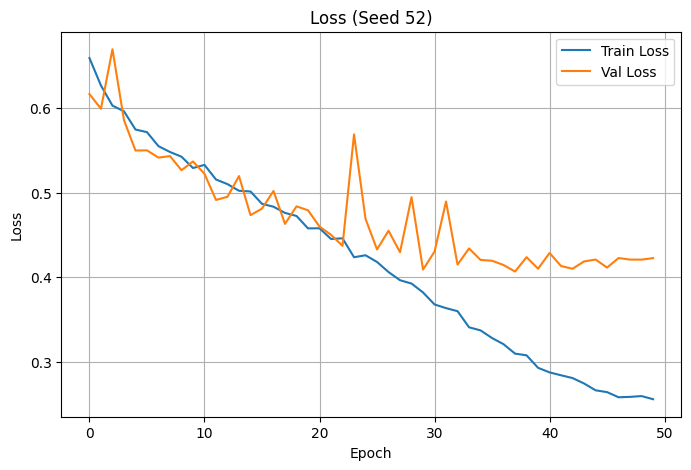

In [19]:
# =====================================================
# Loss Plot
# =====================================================

plt.figure(figsize=(8, 5))
plt.plot(best_result["train_losses"], label="Train Loss")
plt.plot(best_result["val_losses"], label="Val Loss")
plt.title(f"Loss (Seed {best_result['seed']})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

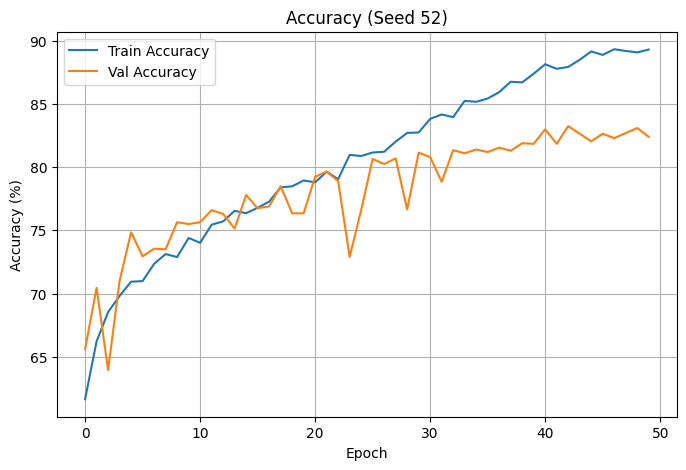

In [20]:
# =====================================================
# Accuracy Plot
# =====================================================

plt.figure(figsize=(8, 5))
plt.plot([x * 100 for x in best_result["train_accs"]], label="Train Accuracy")
plt.plot([x * 100 for x in best_result["val_accs"]], label="Val Accuracy")
plt.title(f"Accuracy (Seed {best_result['seed']})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()